# Cross-Validation

*How to trust your model's score - and how to keep yourself honest.🗣️*

```{admonition} Where we are
:class: tip
So now that we know **bias–variance trade-off** - We saw that a model can be *too simple* (high bias, it underfits) or *too flexible* (high variance, it overfits). The best model sits in the sweet spot in between.

This raises one big question: **in real life, how do we actually find that sweet spot?** We can't see the true curve. We only have a pile of measurements.

This is where Cross-validation comes in. It is the everyday tool that turns the bias–variance *idea* into something you can *do*.
```



## A quick look back

Remember, as we make a model more flexible:

- the **bias** goes *down* (a flexible model can bend to fit the pattern), but
- the **variance** goes *up* (a flexible model also bends to fit the noise).

The error on new data is the sum of the two, so it makes a **U-shape**. The bottom of the U is the model we want.

<img src="images/lec06_bias_variance_curve.png" width="700">


## The problem: one split is a gamble

What we have been doing so far is a train-test split where we hold some data aside, train on the rest, and check the score on the held-out part. Simple and sensible!

However,...

```{admonition} A tiny analogy 📝
:class: note
📚 Imagine you are studying for an exam using a book of 100 practice questions. You quiz yourself on 30 of them and get a great score during the practice session. Are you *sure* you're ready for the final exam?

Maybe those 30 questions just happened to be the easy ones. A different set of 30 questions might have gotten you in trouble. **Your score depends on which questions you picked.**
```

The same thing can happen with a single train/test split!

In materials work our datasets are often **small** (measuring samples is slow and expensive!), and that makes the problem worse. Let's see it.

Below: the *same* dataset and the *same* model (you can refer to the code if that helps, or simply focus on the graph). 
But each time we change the random split, and keep track of the $r^2$ value.
The **only** thing we change is which points land in the test set. Watch the score jump around.


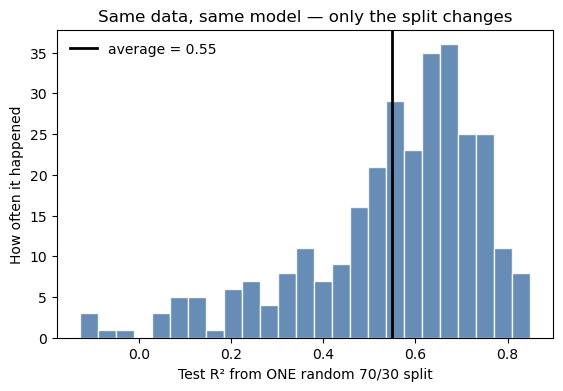

Worst split R² = -0.13
Best  split R² = 0.85
So the 'score' of this model could be reported as anything from -0.13 to 0.85 — just by choosing the split!


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# One small, synthetic dataset (illustrative — not real measurements).
rng = np.random.default_rng(0)
n = 40
x = np.sort(rng.uniform(0, 1, n))
true = np.sin(2.2*np.pi*x)*0.8 + 1.5*x          # the (unknown) true relationship
y = true + rng.normal(0, 0.35, n)               # our noisy measurements
X = x.reshape(-1, 1)

# A fixed, reasonable model. We never change it.
model = make_pipeline(PolynomialFeatures(4), LinearRegression())

# Try 300 different random 70/30 splits and record each test score.
scores = []
for seed in range(300):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.30, random_state=seed)
    model.fit(Xtr, ytr)
    scores.append(r2_score(yte, model.predict(Xte)))
scores = np.array(scores)

#Plot
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.hist(scores, bins=25, color="#4C78A8", alpha=0.85, edgecolor="white")
ax.axvline(scores.mean(), color="black", lw=2, label=f"average = {scores.mean():.2f}")
ax.set_xlabel("Test R\u00b2 from ONE random 70/30 split")
ax.set_ylabel("How often it happened")
ax.set_title("Same data, same model \u2014 only the split changes")
ax.legend(frameon=False)
plt.show()

# Printout the best and worst values
print(f"Worst split R\u00b2 = {scores.min():.2f}")
print(f"Best  split R\u00b2 = {scores.max():.2f}")
print(f"So the 'score' of this model could be reported as anything from "
      f"{scores.min():.2f} to {scores.max():.2f} \u2014 just by choosing the split!")



**❗See the problem?** 

With one unlucky split we might throw away a good model 😱. 

With one lucky split we might brag about a bad one 😎. 

We need something steadier.

## The fix: let everyone take a turn

🧍‍♂️🧍🧍‍♀️🧍🧍‍♂️

The idea of **cross-validation** is of fairness:

Instead of just one train-test split, we do many test splits- one at a time.

> Cut the data into **K equal folds**. Then play the train/test game **K times**. Each time, a different fold sits out as the test set, and the model trains on the other K−1 folds. Finally, **average** the K scores.

This way **every point is tested exactly once**, and no data is wasted.

```{admonition} Two more analogies 🍲
:class: note
- **Tasting the soup.** A chef shouldn't judge the soup from one spoonful in one corner of the pot. Stir, and taste several spoonfuls. The average taste is trustworthy.
- **Quality control.** You don't test reliability from one sample of one batch. You test across batches, then report the average *and* how much the batches varied.
```

Here is the classic picture for **K = 5**:

<img src="images/lec06_5_fold_XV.png" width="700">


## The maths

Say our data has $n$ points. We split the point-numbers into $K$ folds $F_1, \dots, F_K$. Let $\hat f^{(-k)}$ be the model trained on **everything except fold $k$**. For a regression task the cross-validation error is just the average of the folds' errors:

$$
\text{CV}_K \;=\; \frac{1}{K}\sum_{k=1}^{K}\, \text{MSE}_k,
\qquad
\text{MSE}_k \;=\; \frac{1}{|F_k|}\sum_{i \in F_k}\bigl(y_i - \hat f^{(-k)}(x_i)\bigr)^2 .
$$

Two nice things come out of this:

1. **Every point is used.** Each point is a *test* point once and a *training* point $K-1$ times. For small materials datasets, that efficiency is gold.
2. **A steadier estimate.** One split gives one noisy number. CV averages $K$ of them, so the estimate wobbles less. (The folds share training data, so it is not a perfect $1/K$ reduction - but it still helps a lot.)

```{admonition} How big should K be?  A small trade-off inside the trade-off
:class: tip
- **Small K** (say 2): each training set is much smaller than your full data, so the model is handicapped and CV can look *worse* than the truth (pessimistic)😟.
- **Large K** (up to K = n): training sets are almost the whole dataset, so the estimate is nearly unbiased - but it costs many fits and the folds become very similar.
- **K = 5 or K = 10** is the popular middle ground and works well in practice. This is the standard advice in the references at the end 😉.
```

```{dropdown} ✏️ For the curious: leave-one-out (LOOCV) has a shortcut
When $K = n$ (each fold is a single point) we call it **leave-one-out** cross-validation. Normally that means fitting the model $n$ times - expensive. But for ordinary linear regression there is a lovely shortcut that needs just **one** fit:

$$
\text{CV}_{(n)} \;=\; \frac{1}{n}\sum_{i=1}^{n}\left(\frac{y_i - \hat f(x_i)}{1 - h_{ii}}\right)^2 ,
$$

where $h_{ii}$ is the "leverage" of point $i$ (a diagonal entry of the hat matrix). No need to memorise it - just know that LOOCV is not always as slow as it looks.
```


## Cross-validation finds the sweet spot for us 🎯 

We take a new toy dataset - say a material **property** that depends on a **composition fraction** - and we ask CV to choose the polynomial degree. The true relationship is a gentle cubic (degree 3), but *we pretend we don't know that* 😇.

We compare two curves:
- **training error** - always drops as the model gets more flexible (it just memorises more);
- **CV error** - drops, bottoms out, then climbs. The bottom is our sweet spot.


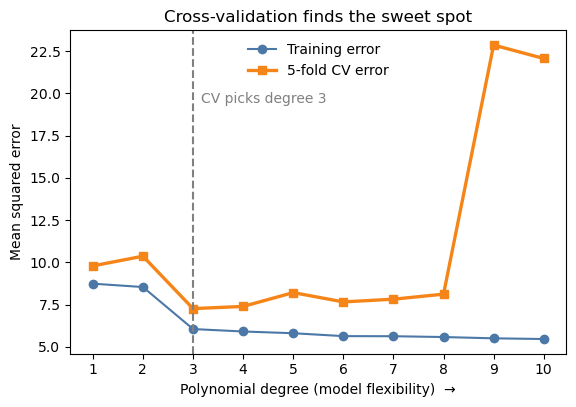

CV chose degree 3.  The true relationship was degree 3.
Training error keeps falling — if we trusted THAT, we'd pick a silly wiggly model.


In [16]:
# Toy "property vs composition" data (illustrative — not real measurements).
from sklearn.model_selection import KFold, cross_val_score 

rng = np.random.default_rng(0)
n = 60
comp = np.sort(rng.uniform(0, 1, n))                       # a composition fraction, 0..1
true_prop = 40 + 60*comp - 90*comp**2 + 55*comp**3         # unknown true property curve
prop = true_prop + rng.normal(0, 2.5, n)                   # measured property (with noise)
Xc = comp.reshape(-1, 1)

cv = KFold(n_splits=5, shuffle=True, random_state=0)       # random_state fixes the folds
degrees = range(1, 11)
cv_mse, train_mse = [], []

for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression())
    # cross_val_score does the whole K-fold loop for us:
    neg = cross_val_score(m, Xc, prop, cv=cv, scoring="neg_mean_squared_error")
    cv_mse.append(-neg.mean())                             # sklearn returns *negative* MSE
    m.fit(Xc, prop)
    train_mse.append(mean_squared_error(prop, m.predict(Xc)))
cv_mse, train_mse = np.array(cv_mse), np.array(train_mse)
best_d = list(degrees)[int(np.argmin(cv_mse))]

#Plots
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(list(degrees), train_mse, "o-", color="#4C78A8", label="Training error")
ax.plot(list(degrees), cv_mse,    "s-", color="#F58518", lw=2.4, label="5-fold CV error")
ax.axvline(best_d, ls="--", color="gray")
ax.text(best_d+0.15, cv_mse.max()*0.85, f"CV picks degree {best_d}", color="gray")
ax.set_xlabel("Polynomial degree (model flexibility)  \u2192")
ax.set_ylabel("Mean squared error"); ax.set_xticks(list(degrees))
ax.set_title("Cross-validation finds the sweet spot")
ax.legend(frameon=False)
plt.show()

print(f"CV chose degree {best_d}.  The true relationship was degree 3.")
print("Training error keeps falling \u2014 if we trusted THAT, we'd pick a silly wiggly model.")


Notice the shapes. **Training error** slides down forever, telling us that the model is fitting better and better. **CV error** is honest: it dips to the true degree and then punishes overfitting. This U-shape is exactly the bias–variance curve - now drawn from cross-validation data we actually have.


## Read the whole result: the mean *and* the spread

A CV score is really $K$ numbers. Reporting only their average throws away useful information. Always report the **spread** too - how much the folds disagreed. A tidy way to write it is **mean ± standard deviation**.

- Small spread → the model behaves the same on every slice of data. Reassuring. 😊
- Large spread → performance depends a lot on *which* samples you test on. Be careful.


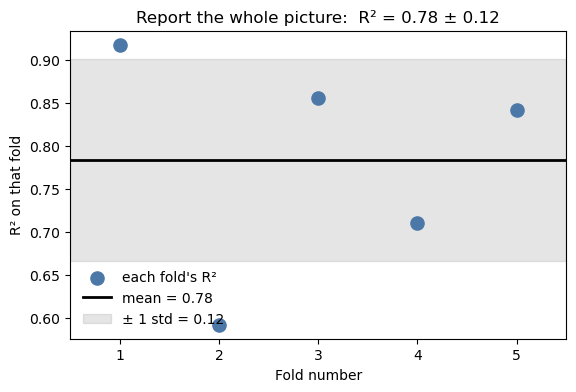

Fold R² values: [0.92 0.59 0.86 0.71 0.84]
Report this as:  R² = 0.78 ± 0.12


In [18]:
# Look at the individual fold scores for the model CV liked best.
best_model = make_pipeline(PolynomialFeatures(best_d), LinearRegression())
fold_r2 = cross_val_score(best_model, Xc, prop, cv=cv, scoring="r2")

fig, ax = plt.subplots(figsize=(6.4, 4.0))
xs = np.arange(1, len(fold_r2)+1)
ax.scatter(xs, fold_r2, s=90, color="#4C78A8", zorder=3, label="each fold's R\u00b2")
ax.axhline(fold_r2.mean(), color="black", lw=2, label=f"mean = {fold_r2.mean():.2f}")
ax.fill_between([0.5, len(fold_r2)+0.5],
                fold_r2.mean()-fold_r2.std(), fold_r2.mean()+fold_r2.std(),
                color="gray", alpha=0.2, label=f"\u00b1 1 std = {fold_r2.std():.2f}")
ax.set_xticks(xs); ax.set_xlim(0.5, len(fold_r2)+0.5)
ax.set_xlabel("Fold number"); ax.set_ylabel("R\u00b2 on that fold")
ax.set_title(f"Report the whole picture:  R\u00b2 = {fold_r2.mean():.2f} \u00b1 {fold_r2.std():.2f}")
ax.legend(frameon=False, loc="lower left")
plt.show()

print("Fold R\u00b2 values:", np.round(fold_r2, 2))
print(f"Report this as:  R\u00b2 = {fold_r2.mean():.2f} \u00b1 {fold_r2.std():.2f}")


```{dropdown} 🍨 A few flavours of cross-validation (good to know)
- **Stratified K-fold** - for classification, keeps the class balance the same in every fold. Handy when one material class is rare. We will run into this later when we look at classification models like SVM or Random Forests.
- **Leave-one-out (LOOCV)** - each fold is a single sample. Good for very small datasets; slower.
- **Grouped / leave-one-group-out** - if several rows come from the *same batch, wafer, or paper*, keep the whole group together in one fold. Otherwise the model can "peek" at a sibling sample and look better than it really is.
- **A materials caution ⚠️** - random folds assume new data looks like old data. If you actually want to *extrapolate* to a new composition range or a new material family, split **by** that range on purpose. A rosy random-CV score can hide a poor extrapolator.
```


## Why report CV scores? 

**Honesty is the best policy**

Here is the part that matters for your careers, not just your grades.

Cross-validation gives an *honest* score. But honesty can still be quietly undone. Suppose you try **many** models, features, or settings, and then report only the **best-looking** one. That best number is partly **skill** and partly **luck** - and you've kept the lucky one without saying so.

```{admonition} The lottery analogy 🎟️
:class: warning
Give one person a lottery ticket and they probably lose. Give *ten thousand* people a ticket each and someone wins big. That doesn't mean there's a good chance of winning the lottery - they are just the luckiest of many tries.

Trying 50 models and reporting the best one is the same trick. This is the heart of **p-hacking**: with enough attempts, pure noise can look like a discovery.
```

Let's prove it to ourselves. We invent a target with **no real pattern at all** - literally a coin flip. Then we try 50 random "ideas" and keep the best cross-validation accuracy. Chance is 50%. Watch what "the best of 50" looks like.

Scenario is explained below the graphs.


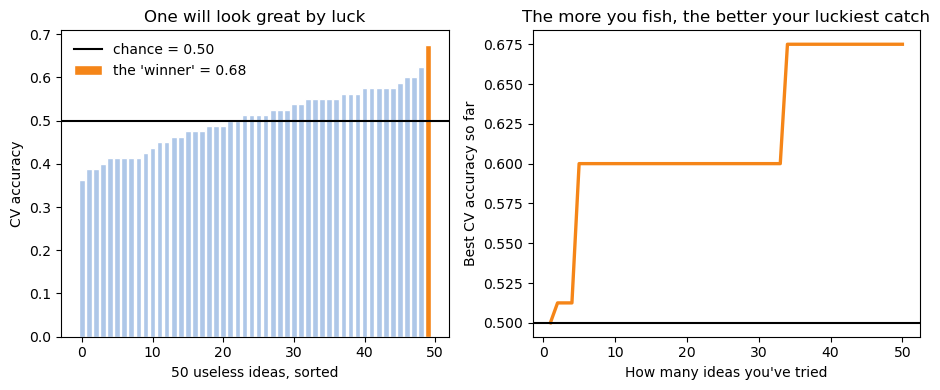

Is there any real pattern to find?   NO (it's a coin flip).
Average CV accuracy over all ideas:  0.51   (chance is 0.50)
Best CV accuracy we could brag about: 0.68  😱
That same 'winner' on FRESH data:     0.38   ← back to luck


In [22]:
# A target with NO real signal: a fair coin flip. Balanced classes.

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(0)
n = 80
y_coin = np.array([0, 1] * (n // 2)); rng.shuffle(y_coin)
cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Try 50 useless "ideas" (each is a brand-new random feature) and score each with CV.
M = 50
accs = []
for _ in range(M):
    X_useless = rng.normal(0, 1, (n, 1))
    accs.append(cross_val_score(LogisticRegression(), X_useless, y_coin,
                                cv=cv2, scoring="accuracy").mean())
accs = np.array(accs)
winner = accs.max()

# Reality check: take the "winning" idea and try it on a FRESH coin-flip dataset.
fy = np.array([0, 1] * (n // 2)); rng.shuffle(fy)
fresh = cross_val_score(LogisticRegression(), rng.normal(0, 1, (n, 1)), fy,
                        cv=cv2, scoring="accuracy").mean()

fig, ax = plt.subplots(1, 2, figsize=(9.4, 4.0))
# left: all 50 ideas, sorted, winner highlighted
order = np.argsort(accs)
ax[0].bar(range(M), accs[order], color="#AEC7E8", edgecolor="white")
ax[0].bar([M-1], [accs[order][-1]], color="#F58518", edgecolor="white",
          label=f"the 'winner' = {winner:.2f}")
ax[0].axhline(0.5, color="black", lw=1.5, label="chance = 0.50")
ax[0].set_xlabel("50 useless ideas, sorted"); ax[0].set_ylabel("CV accuracy")
ax[0].set_title("One will look great by luck"); ax[0].legend(frameon=False, loc="upper left")
# right: running best as you try more ideas
run_best = np.maximum.accumulate(accs)
ax[1].plot(range(1, M+1), run_best, color="#F58518", lw=2.4)
ax[1].axhline(0.5, color="black", lw=1.5)
ax[1].set_xlabel("How many ideas you've tried"); ax[1].set_ylabel("Best CV accuracy so far")
ax[1].set_title("The more you fish, the better your luckiest catch")
plt.tight_layout(); plt.show()

print(f"Is there any real pattern to find?   NO (it's a coin flip).")
print(f"Average CV accuracy over all ideas:  {accs.mean():.2f}   (chance is 0.50)")
print(f"Best CV accuracy we could brag about: {winner:.2f}  \U0001F631")
print(f"That same 'winner' on FRESH data:     {fresh:.2f}   \u2190 back to luck")


"Idea" here is a stand-in for "candidate feature or predictor" - as in, an idea a researcher might have for what could predict the target (e.g., "maybe this measurement matters," "maybe that ratio matters"). In this toy demo it's deliberately meaningless: each "idea" is nothing but a fresh column of random Gaussian noise `(X_useless = rng.normal(0, 1, (n, 1)))`, generated 50 times in the loop, and scored against `y_coin` - a target that's nothing but a coin flip, unrelated to anything.

So the simulation is playing out this scenario: you try 50 different features, one at a time, hoping one predicts the outcome. Since `y_coin` has literally no real signal to find, every one of those 50 "ideas" is equally useless. But `cross_val_score` on each still returns a range of accuracies, some by pure chance sitting well above 0.50 - that's what `winner = accs.max()` captures, and the plot's orange bar highlights it.

Here Cross-Validation is doing its job correctly on each individual idea. The problem is what happens when you try many ideas and only report the best one: pure luck guarantees some "idea" will look good on any finite sample, coin-flip target or not. That's why the script finishes with a "reality check" - taking that winning idea and testing it on a brand-new coin-flip dataset it's never touched (fresh), where its accuracy drops back toward 0.50. So, a good CV score on data you used to go searching for winners isn't trustworthy on its own; you need a held-out check that wasn't part of the search.

The "winner" looked clever, but on fresh data it fell back to a coin flip. Nothing was learned - we only measured luck.

```{admonition} So what keeps us honest?
:class: tip
- **Report your CV score with its spread**, e.g. `0.82 ± 0.05` - not a single cherry-picked number.
- **Say how many things you tried.** "We tested 12 models" is part of the result.
- **Keep a final test set you touch once.** After all your searching, confirm the winner on data it has never seen.
- **Watch for peeking.** Any scaling, feature-picking, or tuning must happen *inside* the CV loop, using only the training folds. (More on this leakage trap in a later lecture.)
```

This is what makes a materials ML result **reproducible** and believable. A reported CV score with its spread is a small promise: *"I didn't just get lucky, and here's how sure I am."*

One of the biggest problems with research is *reproducing* another paper's work - and this might be due to some laboratory practice that the researchers didn't report,  an evironment variable or a statistical error like this one.


## Your turn 

```{admonition} Practice
:class: note
You cross-validate two models on the same dataset and get:

- **Model A:** R² = 0.80 ± 0.03
- **Model B:** R² = 0.83 ± 0.15

Which model would you trust to work on a new batch of samples, and why? Write **two sentences**.
```

```{dropdown} Solution ✅ 
There is no single "correct" answer, but a strong response notices the **spread**, not just the mean.

Model B has a slightly higher average, but its large ±0.15 spread means its performance swings a lot depending on which samples it sees - risky on a fresh batch. Model A is a touch lower on average but very steady (±0.03), so it is the safer bet to generalise. A great answer also suggests confirming the choice on a final held-out test set.
```


## Summary

```{admonition} The one-screen version
:class: tip
- A **single split** gives a noisy score - especially for small materials datasets.
- **K-fold cross-validation** gives everyone a turn as the test set and averages the results, for a steadier estimate.
- **K = 5 or 10** is the usual choice; LOOCV is the small-data extreme.
- Always report the **mean and the spread** (e.g. `0.82 ± 0.05`).
- CV lets us **find the bias–variance sweet spot** from real data.
- Reporting CV scores honestly - including how many things you tried - is your defence against **p-hacking**.
```

Next time we'll build on this to tune regularisation strength, where cross-validation does the heavy lifting.


<img src="images/lec06_p_hacking.png" width="700">

